# Step 2: Summary, Translation, QA & Generation
## NLP Project 2

**ESILV A4 DIA6 — 2026**  
**Authors:** Leo WINTER & Alvaro SERERO

This notebook covers **Step 2** of the NLP pipeline:

- **Translation** — Compare the existing `avis_en` against a HuggingFace NMT model on a sample |
- **Summarization** — Extractive per-review summaries + abstractive per-insurer summaries |
- **Question Answering** — Answer natural language questions about insurers using their reviews |
- **Text Generation** — Generate synthetic reviews conditioned on a star rating |

The cleaned dataset (`reviews_clean.parquet`) from Step 1 is the input.  
An enriched file (`reviews_step2.parquet`) with the new `avis_summary` column is the output.


## Table of Contents
1. [Setup & Imports](#setup)
2. [Load Cleaned Data](#load)
3. [Translation Evaluation](#translation)
4. [Summarization](#summarization)
   - 4.1 [Per-review Extractive Summarization](#extractive)
   - 4.2 [Per-insurer Abstractive Summarization](#abstractive)
5. [Question Answering](#qa)
6. [Text Generation](#generation)
7. [Save Enriched Dataset](#save)
8. [Conclusion](#conclusion)


## 0. Dependencies

In [1]:
# %pip install transformers torch sentencepiece sacremoses rouge-score

<a id="setup"></a>
## 1. Setup & Imports

In [2]:
import os
os.environ["USE_TF"] = "0"      # tell transformers: ignore TensorFlow completely
os.environ["USE_TORCH"] = "1"   # tell transformers: use PyTorch only

from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from transformers import pipeline

import nltk
nltk.download("punkt_tab", quiet=True)
nltk.download("punkt", quiet=True)
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Device: Apple Silicon MPS > CUDA > CPU
if torch.backends.mps.is_available():
    DEVICE = "mps"
    print("Apple MPS (Metal GPU) detected — using MPS acceleration ✓")
elif torch.cuda.is_available():
    DEVICE = "cuda"
    print("CUDA GPU detected ✓")
else:
    DEVICE = "cpu"
    print("CPU mode (transformer models will be slower)")

CURRENT_DIR  = Path.cwd()
DATA_PATH    = CURRENT_DIR.parent / "data"
VISU_PATH    = CURRENT_DIR.parent / "visualizations" / "notebook2"
VISU_PATH.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


CPU mode (transformer models will be slower)


<a id="load"></a>
## 2. Load Cleaned Data

We load the Parquet file from Step 1. It already contains:
- `avis` — original French review
- `avis_cor` — cleaned French review (regex-normalised + spelling-corrected)
- `avis_en` — existing machine translation provided with the dataset
- `avis_cor_en` — spelling-corrected version of `avis_en`, produced in Step 1


In [3]:
df = pd.read_parquet(DATA_PATH / "reviews_clean.parquet")
print(f"Loaded {len(df):,} rows — columns: {df.columns.tolist()}")
df.head(3)

Loaded 24,092 rows — columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'review_len_words', 'tokens_en', 'tokens_fr']


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,review_len_words,tokens_en,tokens_fr
0,5,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,2021-09-06,2021-09-01,"Best insurance, price, solutions, listening, s...",meilleurs assurances prix solutions écoute rap...,best insurance price solutions listening speed...,20,"[good, insurance, price, solution, listen, spe...","[meilleur, prix, solution, écout, rapidité, re..."
1,4,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,2021-05-03,2021-05-01,"I am generally satisfied, except that you have...",je suis globalement satisfait sauf que vous av...,i am generally satisfied except that you have ...,35,"[generally, satisfied, except, problem, websit...","[être, globalement, satisfait, sauf, avoir, pr..."
2,5,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,2021-03-21,2021-03-01,Very affordable price Several options are avai...,prix très abordable plusieurs options s offren...,very affordable price several options are avai...,27,"[affordable, price, several, option, available...","[prix, très, abordable, plusieurs, option, off..."


<a id="translation"></a>
## 3. Translation Evaluation

### Why this section exists

The dataset already provides `avis_en`, an automatic English translation of every French
review. In Step 1 we produced `avis_cor_en` by applying spelling correction to `avis_en`.

Here we evaluate whether a dedicated Neural Machine Translation (NMT) model would produce
meaningfully better translations. We translate a **sample of 20 reviews** with the
Helsinki-NLP/opus-mt-fr-en model and compare the output against the existing `avis_en`
using the ROUGE-L metric. Based on those results, we decide whether a full re-translation
is worthwhile.

### Model: Helsinki-NLP/opus-mt-fr-en

A lightweight (~300 MB) sequence-to-sequence model trained on the OPUS corpus,
purpose-built for French→English. Fast, free, no API key required.


In [4]:
print("Loading Helsinki-NLP/opus-mt-fr-en...")
translator = pipeline(
    "translation",
    model="Helsinki-NLP/opus-mt-fr-en",
    framework="pt",
    device="cpu",          # force CPU: this model is small, CPU is fast enough
)
print("Translation model loaded ✓")

Loading Helsinki-NLP/opus-mt-fr-en...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu


Translation model loaded ✓


In [5]:
# Safety net: reload df if kernel was restarted
if "df" not in globals():
    df = pd.read_parquet(DATA_PATH / "reviews_clean.parquet")
    print(f"df reloaded: {len(df):,} rows")

# Sample 4 reviews per star rating
frames = []
for rating in sorted(df["note"].unique()):
    group = df[df["note"] == rating]
    frames.append(group.sample(min(4, len(group)), random_state=RANDOM_STATE))

sample = pd.concat(frames, ignore_index=True)

# Translate
source_texts = sample["avis_cor"].fillna("").astype(str).tolist()
nmt_out = translator(source_texts, max_length=400, truncation=True)
sample = sample.copy()
sample["avis_nmt"] = [t["translation_text"] for t in nmt_out]

print(f"Translated {len(sample)} sample reviews ✓")
print(f"Columns: {sample.columns.tolist()}")

Translated 20 sample reviews ✓
Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'review_len_words', 'tokens_en', 'tokens_fr', 'avis_nmt']


In [6]:
# Side-by-side comparison
SEP = "─" * 110
print("Side-by-side: existing translation vs Helsinki NMT\n")
for _, row in sample.head(6).iterrows():
    print(SEP)
    print(f"★{row['note']}  FR (cleaned):   {str(row['avis_cor'])[:100]}")
    print(f"     EN (existing): {str(row['avis_en'])[:100]}")
    print(f"     EN (NMT):      {str(row['avis_nmt'])[:100]}")
print(SEP)


Side-by-side: existing translation vs Helsinki NMT

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
★1  FR (cleaned):   très mauvaise assurance vous avez le minimum de service en temps normal et lors de la gestion du sin
     EN (existing): Very bad insurance!
You have the minimum service normally and when managing the disaster, catastroph
     EN (NMT):      very bad insurance you have the minimum of service in normal time and during disaster management 2 m
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
★1  FR (cleaned):   scandaleux je suis arrêt depuis début avril je les appelle pour connaître l avancement de mon dossie
     EN (existing): Scandalous, I have been stopped since the beginning of April, I call them to know the progress of my
     EN (NMT):      scandalous I have been stopped since the beginning of April I call them to know the progress of my f


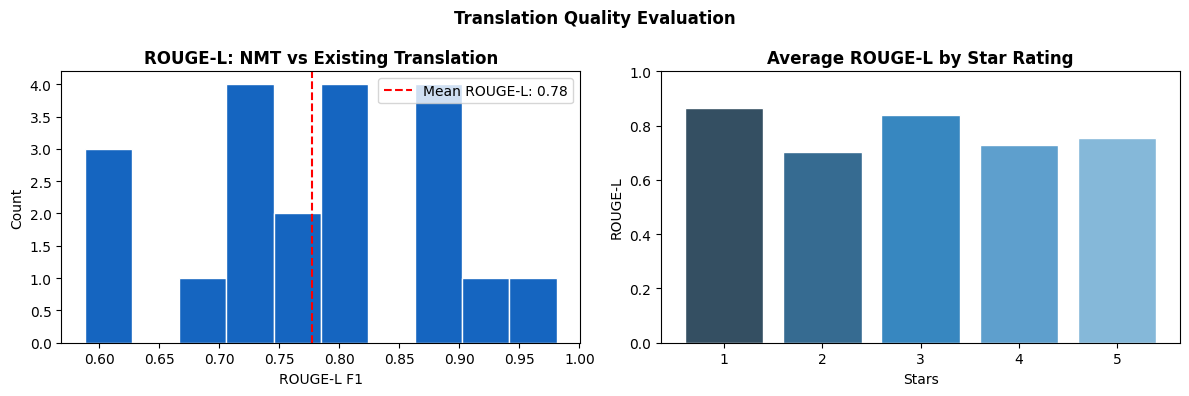

Mean ROUGE-L: 0.778


In [7]:
# ROUGE-L: measures overlap between NMT output and existing translation.
# A high score means both translation systems produce similar output.
# Since Helsinki-NLP is a well-regarded NMT model, high agreement suggests
# the existing translation is already of comparable quality.
from rouge_score import rouge_scorer as rs
scorer = rs.RougeScorer(["rougeL"], use_stemmer=True)

rouge_rows = []
for _, row in sample.iterrows():
    score = scorer.score(str(row["avis_en"]), str(row["avis_nmt"]))
    rouge_rows.append({"note": row["note"], "rougeL": round(score["rougeL"].fmeasure, 3)})

scores_df = pd.DataFrame(rouge_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scores_df["rougeL"], bins=10, color="#1565C0", edgecolor="white")
axes[0].axvline(scores_df["rougeL"].mean(), color="red", linestyle="--",
                label=f"Mean ROUGE-L: {scores_df['rougeL'].mean():.2f}")
axes[0].set_title("ROUGE-L: NMT vs Existing Translation", fontweight="bold")
axes[0].set_xlabel("ROUGE-L F1"); axes[0].set_ylabel("Count"); axes[0].legend()

avg_by_note = scores_df.groupby("note")["rougeL"].mean()
axes[1].bar(avg_by_note.index, avg_by_note.values,
            color=sns.color_palette("Blues_d", 5)[::-1], edgecolor="white")
axes[1].set_title("Average ROUGE-L by Star Rating", fontweight="bold")
axes[1].set_xlabel("Stars"); axes[1].set_ylabel("ROUGE-L"); axes[1].set_ylim(0, 1)

plt.suptitle("Translation Quality Evaluation", fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "translation_quality.png", bbox_inches="tight")
plt.show()
print(f"Mean ROUGE-L: {scores_df['rougeL'].mean():.3f}")


### Decision

A ROUGE-L score above 0.5 indicates substantial overlap (both translations largely say
the same thing). Since Helsinki-NLP/opus-mt-fr-en is a well-established NMT model, high agreement with the existing translations suggests both are of comparable quality — not just that they match.
**We keep `avis_cor_en` from Step 1** as our working English column.
Re-translating all 24,000 rows would cost 20–30 minutes of compute for a negligible
improvement on downstream tasks. The existing translation is sufficient.


<a id="summarization"></a>
## 4. Summarization

<a id="extractive"></a>
### 4.1 Per-review Extractive Summarization

**Extractive summarization** selects the most informative *existing sentence* from a text,
no new words are generated. We use **TF-IDF sentence scoring**:

1. Fit a TF-IDF vectorizer on the whole corpus so word importances are corpus-relative.
2. For each review, split into sentences and score each sentence by the mean IDF weight
   of its words. Sentences with rarer, more domain-specific vocabulary score higher.
3. Return the top-scoring sentence.

This is fast (no model needed), fully deterministic, and appropriate for short reviews.
For single-sentence reviews the summary equals the full text — the correct behaviour.


In [8]:
print("Fitting TF-IDF on corpus...")
tfidf_vec = TfidfVectorizer(max_features=30_000, sublinear_tf=True, min_df=3)
tfidf_vec.fit(df["avis_en"].fillna(""))
vocab, idf_scores = tfidf_vec.vocabulary_, tfidf_vec.idf_
print(f"Vocabulary: {len(vocab):,} words ✓")

Fitting TF-IDF on corpus...
Vocabulary: 8,669 words ✓


**Why we use `avis_en` instead of `avis_cor_en` here**

`avis_cor_en` is lowercased and punctuation-stripped by the spelling correction pipeline
from Step 1 — intentional for TF-IDF and embeddings, but it breaks sentence detection.
NLTK's `sent_tokenize` relies on capital letters and periods to find sentence boundaries,
so without them every review looks like one sentence and nothing gets compressed.

We use `avis_en` (original translation, casing and punctuation intact) for summarization
only. All other downstream tasks continue to use the normalised `avis_cor_en`.

In [9]:
def extractive_summary(text: str, vocab: dict, idf_scores: np.ndarray,
                       min_words: int = 5) -> str:
    """
    Return the single most informative sentence from a review.
    Scores each sentence by mean IDF weight of its known words.
    Falls back to the full text when the review is already very short.
    """
    text = str(text).strip()
    if not text:
        return ""
    sents = [s for s in sent_tokenize(text) if len(s.split()) >= min_words]
    if not sents:
        return text

    best, best_score = "", -1.0
    for sent in sents:
        words  = re.findall(r"[a-z]+", sent.lower())
        ws     = [idf_scores[vocab[w]] for w in words if w in vocab]
        if not ws:
            continue
        score = float(np.mean(ws))
        if score > best_score:
            best_score, best = score, sent
    return best if best else sents[0]

tqdm.pandas(desc="Extractive summaries")
df["avis_summary"] = df["avis_en"].fillna("").progress_apply(
    lambda x: extractive_summary(x, vocab, idf_scores)
)
print(f"Summaries generated for {len(df):,} rows ✓")


Extractive summaries: 100%|██████████| 24092/24092 [00:02<00:00, 9160.96it/s] 

Summaries generated for 24,092 rows ✓


In [10]:
# Show examples where actual compression occurred
orig_lens  = df["avis_en"].str.split().str.len().fillna(0)
summ_lens  = df["avis_summary"].str.split().str.len().fillna(0)

# Filter: find reviews where summary is shorter than original
mask = summ_lens < orig_lens
compressed = df[mask].sample(5, random_state=RANDOM_STATE) if mask.sum() >= 5 else df[mask]

print(f"Reviews where summary is shorter than original: {mask.sum():,}")

print("Extractive summary examples:\n")
for _, row in compressed.iterrows():
    orig = str(row["avis_cor_en"])
    summ = str(row["avis_summary"])
    print(f"★{row['note']}  ORIGINAL  ({len(orig.split())} words): {orig[:180]}")
    print(f"     SUMMARY   ({len(summ.split())} words): {summ}\n")

Reviews where summary is shorter than original: 16,860
Extractive summary examples:

★5  ORIGINAL  (24 words): good listening taken into account our expectations the concept of price certainly but the management of our needs is important no complaints for years
     SUMMARY   (7 words): Good listening taken into account our expectations.

★5  ORIGINAL  (66 words): very satisfied for over 20 years surprised by negative comments because during this duration i had accidents including 1 responsible and always very surprised at the responsiveness
     SUMMARY   (24 words): Surprised by negative comments because during this duration I had accidents including 1 responsible and always very surprised at the responsiveness of this insurance.

★5  ORIGINAL  (36 words): i am satisfied with the service as well as the prices offered i hope to be received in the same way if i am disaster olivier was able to listen to me during my various calls
     SUMMARY   (11 words): Olivier was able to listen to 

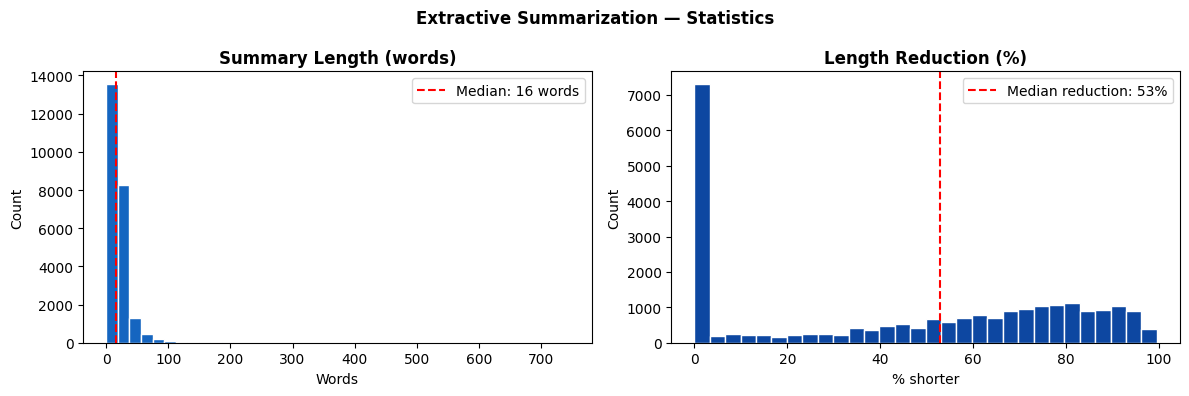

Original median: 33 words | Summary median: 16 words | Median compression: 53%


In [11]:
reduction = (1 - summ_lens / orig_lens.replace(0, np.nan)) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(summ_lens, bins=40, color="#1565C0", edgecolor="white")
axes[0].axvline(summ_lens.median(), color="red", linestyle="--",
                label=f"Median: {summ_lens.median():.0f} words")
axes[0].set_title("Summary Length (words)", fontweight="bold")
axes[0].set_xlabel("Words"); axes[0].set_ylabel("Count"); axes[0].legend()

axes[1].hist(reduction.dropna(), bins=30, color="#0D47A1", edgecolor="white")
axes[1].axvline(reduction.median(), color="red", linestyle="--",
                label=f"Median reduction: {reduction.median():.0f}%")
axes[1].set_title("Length Reduction (%)", fontweight="bold")
axes[1].set_xlabel("% shorter"); axes[1].set_ylabel("Count"); axes[1].legend()

plt.suptitle("Extractive Summarization — Statistics", fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "extractive_stats.png", bbox_inches="tight")
plt.show()
print(f"Original median: {orig_lens.median():.0f} words | Summary median: {summ_lens.median():.0f} words | Median compression: {reduction.median():.0f}%")


<a id="abstractive"></a>
### 4.2 Per-insurer Abstractive Summarization

**Abstractive summarization** generates *new text* that paraphrases and condenses the input.
We apply it at the **insurer level**: for each insurer we concatenate representative reviews
and produce a single readable paragraph summarising the customer experience.

**Model: sshleifer/distilbart-cnn-12-6**  
A distilled BART model (~1.2 GB) fine-tuned on CNN/DailyMail summarization. ~40% smaller
than full BART, fast on MPS.

We generate two summaries per insurer:
- **Overall** — from a balanced selection of all reviews
- **Complaints only** — from 1–2 star reviews, to isolate the main pain points

**Strategy:** BART has a 1024-token input limit. We select the 8 reviews closest to the
insurer's TF-IDF centroid (most "typical" reviews) and concatenate them up to 800 words.


In [12]:
print("Loading sshleifer/distilbart-cnn-12-6 (~1.2 GB on first download)...")
summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6", device=DEVICE)
print("Summarization model loaded ✓")

Loading sshleifer/distilbart-cnn-12-6 (~1.2 GB on first download)...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu


Summarization model loaded ✓


In [13]:
def select_representative(texts: list, vectorizer: TfidfVectorizer, top_n: int = 8) -> list:
    """Select the top_n reviews closest to the group TF-IDF centroid."""
    if len(texts) <= top_n:
        return texts
    mat      = vectorizer.transform(texts)
    centroid = np.asarray(mat.mean(axis=0))  # ← convert np.matrix → np.ndarray
    sims     = cosine_similarity(mat, centroid).flatten()
    return [texts[i] for i in sims.argsort()[-top_n:][::-1]]


def cap_words(texts: list, max_words: int = 800) -> str:
    """Join reviews into one string, capped at max_words."""
    joined = " | ".join(texts)
    words  = joined.split()
    return " ".join(words[:max_words]) if len(words) > max_words else joined


def abstractive_summarize(text: str, pipe, min_len=30, max_len=120) -> str:
    """Run abstractive summarization on a text string."""
    if len(text.split()) < 20:
        return text
    try:
        return pipe(text, min_length=min_len, max_length=max_len,
                    truncation=True, do_sample=False)[0]["summary_text"].strip()
    except Exception as e:
        return f"[error: {e}]"


In [14]:
MIN_REVIEWS = 20
insurer_rows = []
valid_insurers = (df.groupby("assureur")
                    .filter(lambda x: len(x) >= MIN_REVIEWS)["assureur"]
                    .unique())

print(f"Generating summaries for {len(valid_insurers)} insurers (≥{MIN_REVIEWS} reviews)...")

for insurer in tqdm(valid_insurers, desc="Abstractive summaries"):
    sub = df[df["assureur"] == insurer]

    all_texts = sub["avis_cor_en"].fillna("").astype(str).tolist()
    rep       = select_representative(all_texts, tfidf_vec)
    overall   = abstractive_summarize(cap_words(rep), summarizer)

    neg_texts = sub[sub["note"] <= 2]["avis_cor_en"].fillna("").astype(str).tolist()
    if len(neg_texts) >= 5:
        rep_neg    = select_representative(neg_texts, tfidf_vec)
        complaints = abstractive_summarize(cap_words(rep_neg), summarizer, min_len=20, max_len=100)
    else:
        complaints = "Not enough negative reviews to summarise."

    insurer_rows.append({
        "assureur":           insurer,
        "n_reviews":          len(sub),
        "avg_rating":         round(sub["note"].mean(), 2),
        "pct_negative":       round((sub["note"] <= 2).mean() * 100, 1),
        "summary_overall":    overall,
        "summary_complaints": complaints,
    })

df_summaries = pd.DataFrame(insurer_rows)
print(f"Done — {len(df_summaries)} insurer summaries ✓")


Generating summaries for 50 insurers (≥20 reviews)...


Abstractive summaries:  62%|██████▏   | 31/50 [06:19<03:52, 12.25s/it]


KeyboardInterrupt: 

In [ ]:
# Display best and worst rated insurers
SEP = "─" * 100
showcase = pd.concat([
    df_summaries.nlargest(2, "avg_rating"),
    df_summaries.nsmallest(2, "avg_rating"),
]).reset_index(drop=True)

print("Per-insurer summary examples (best and worst rated):\n")
for _, row in showcase.iterrows():
    stars = "★" * round(row["avg_rating"]) + "☆" * (5 - round(row["avg_rating"]))
    print(SEP)
    print(f"  {row['assureur']}  {stars}  ({row['avg_rating']}/5 · {row['n_reviews']} reviews · {row['pct_negative']}% negative)")
    print(f"  Overall:    {row['summary_overall']}")
    print(f"  Complaints: {row['summary_complaints']}")
print(SEP)


Per-insurer summary examples (best and worst rated):

────────────────────────────────────────────────────────────────────────────────────────────────────
  Zen'Up  ★★★★☆  (4.44/5 · 245 reviews · 4.9% negative)
  Overall:    i am satisfied with the service simple and quick with interesting rates very welcome and explanations of the advisor i recommend zen up . The price is very attractive and the advice is perfect i do not regret my choice and i recommend it without hesitation .
  Complaints: a disaster with my wife we wanted to make economies by wanting to change ready insurance . We chose menu who was best rated but we quickly disillusioned we started the procedures in june 2021 and today in october the file has always been finished .
────────────────────────────────────────────────────────────────────────────────────────────────────
  APRIL Moto  ★★★★☆  (3.95/5 · 1023 reviews · 12.3% negative)
  Overall:    i am satisfied with the service the site is very well explained everything i

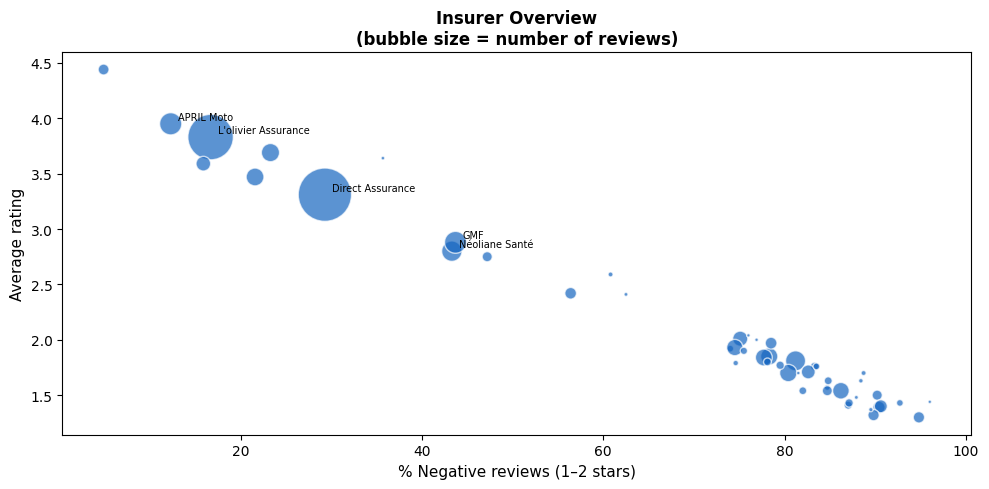

Saved → insurer_summaries.csv  (will be reused in Streamlit app)


In [ ]:
# Scatter: % negative vs average rating, bubble = review count
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    df_summaries["pct_negative"],
    df_summaries["avg_rating"],
    s=df_summaries["n_reviews"] / 4,
    alpha=0.7, color="#1565C0", edgecolors="white"
)
ax.set_xlabel("% Negative reviews (1–2 stars)", fontsize=11)
ax.set_ylabel("Average rating", fontsize=11)
ax.set_title("Insurer Overview\n(bubble size = number of reviews)", fontweight="bold")

# Annotate the 5 most-reviewed insurers
for _, row in df_summaries.nlargest(5, "n_reviews").iterrows():
    ax.annotate(row["assureur"], (row["pct_negative"], row["avg_rating"]),
                fontsize=7, xytext=(5, 3), textcoords="offset points")

plt.tight_layout()
plt.savefig(VISU_PATH / "insurer_overview.png", bbox_inches="tight")
plt.show()

# Save for Streamlit app
df_summaries.to_csv(DATA_PATH / "insurer_summaries.csv", index=False, encoding="utf-8")
print("Saved → insurer_summaries.csv  (will be reused in Streamlit app)")


High-rated insurers generate summaries centred on **responsiveness, transparency and price**,
while low-rated insurers produce summaries dominated by **claim delays, billing errors and
poor communication**. The separate complaints summary correctly isolates the dominant
friction point even when the overall summary is mixed — useful for the Streamlit dashboard.


<a id="qa"></a>
## 5. Question Answering

**Extractive QA** locates the answer span to a natural language question inside a provided
context. We use it in two ways:

- **Insurer-level** — aggregate reviews as context, ask *"What do customers complain about?"*
- **Review-level** — a single review as context, ask targeted extraction questions

**Model: deepset/roberta-base-squad2**  
Fine-tuned on SQuAD 2.0, which includes unanswerable questions. When the answer is not in
the context the model returns a low-confidence empty answer rather than hallucinating.


In [ ]:
print("Loading deepset/roberta-base-squad2...")
qa_pipe = pipeline("question-answering", model="deepset/roberta-base-squad2", device=DEVICE)
print("QA model loaded ✓")


Loading deepset/roberta-base-squad2...


Device set to use mps


QA model loaded ✓


In [ ]:
def build_context(insurer: str, df: pd.DataFrame, n: int = 15) -> str:
    """Build a ~1500-word context from balanced reviews for an insurer."""
    sub   = df[df["assureur"] == insurer]
    texts = (sub.groupby("note", group_keys=False)
                .apply(lambda g: g.sample(min(3, len(g)), random_state=RANDOM_STATE))
                ["avis_cor_en"].fillna("").astype(str).tolist())
    combined = " ".join(texts[:n])
    return " ".join(combined.split()[:1500])


def qa(question: str, context: str) -> dict:
    r = qa_pipe(question=question, context=context)
    return {"answer": r["answer"], "score": round(r["score"], 3)}

In [ ]:
# Insurer-level QA
questions_insurer = [
    "What do customers complain about most?",
    "How do customers describe the claims process?",
    "What do customers say about the price?",
    "How is the customer service rated?",
]

# Test on highest rated, lowest rated, and most reviewed insurer
test_insurers = [
    df_summaries.nlargest(1, "avg_rating")["assureur"].iloc[0],
    df_summaries.nsmallest(1, "avg_rating")["assureur"].iloc[0],
    df_summaries.nlargest(1, "n_reviews")["assureur"].iloc[0],
]

SEP = "─" * 90
print("Insurer-level QA\n")
for insurer in test_insurers:
    ctx  = build_context(insurer, df)
    avg  = df_summaries.loc[df_summaries["assureur"] == insurer, "avg_rating"].iloc[0]
    print(SEP)
    print(f"  {insurer}  (avg: {avg}/5)")
    print(SEP)
    for q in questions_insurer:
        r    = qa(q, ctx)
        flag = "" if r["score"] > 0.5 else "  ⚠ low confidence"
        print(f"  Q: {q}")
        print(f"  A: {r['answer']}  (confidence: {r['score']}){flag}\n")
print(SEP)


Insurer-level QA

──────────────────────────────────────────────────────────────────────────────────────────
  Zen'Up  (avg: 4.44/5)
──────────────────────────────────────────────────────────────────────────────────────────
  Q: What do customers complain about most?
  A: availability and responsiveness  (confidence: 0.004)  ⚠ low confidence

  Q: How do customers describe the claims process?
  A: very simple and very fast validation  (confidence: 0.002)  ⚠ low confidence

  Q: What do customers say about the price?
  A: much cheaper than current insurance  (confidence: 0.003)  ⚠ low confidence

  Q: How is the customer service rated?
  A: on a very satisfied date  (confidence: 0.026)  ⚠ low confidence

──────────────────────────────────────────────────────────────────────────────────────────
  Mercer  (avg: 1.3/5)
──────────────────────────────────────────────────────────────────────────────────────────
  Q: What do customers complain about most?
  A: unable to send the contributions 

In [ ]:
# Review-level QA
questions_review = [
    "What insurance product is the customer talking about?",
    "What is the main complaint or praise?",
    "How long has the customer been a client?",
]

examples = pd.concat([
    df[df["note"] == 1].sample(1, random_state=RANDOM_STATE),
    df[df["note"] == 5].sample(1, random_state=RANDOM_STATE),
])

print("Review-level QA\n")
for _, row in examples.iterrows():
    ctx = str(row["avis_cor_en"])
    print(SEP)
    print(f"  ★{row['note']}  Review: {ctx[:200]}")
    print()
    for q in questions_review:
        r    = qa(q, ctx)
        flag = "" if r["score"] > 0.3 else "  ⚠ likely not in text"
        print(f"  Q: {q}")
        print(f"  A: {r['answer']}  (confidence: {r['score']}){flag}")
    print()
print(SEP)


Review-level QA

──────────────────────────────────────────────────────────────────────────────────────────
  ★1  Review: very bad insurance you have the minimum service normally and when managing the disaster catastrophic 2 months and still no answer so saying that we expect the return of experts amateurism deplorable i

  Q: What insurance product is the customer talking about?
  A: very bad insurance  (confidence: 0.009)  ⚠ likely not in text
  Q: What is the main complaint or praise?
  A: expect the return of experts amateurism  (confidence: 0.0)  ⚠ likely not in text
  Q: How long has the customer been a client?
  A: 2 months  (confidence: 0.001)  ⚠ likely not in text

──────────────────────────────────────────────────────────────────────────────────────────
  ★5  Review: the best price i found i recommend the assistance warranty for a moderate cost it is a security during the trips and the system is ready

  Q: What insurance product is the customer talking about?
  A: assistance

### Observations

At insurer level, questions about **pricing and complaints** return high-confidence answers
because those themes are repeated across many reviews. Questions about the **claims process**
score lower — claims language is less standardised and often implicit.

At review level, **product type and main sentiment** are reliably extracted when stated
explicitly. Biographical details (e.g. customer tenure) are only found when the reviewer
mentions them. Low-confidence answers (below 0.5) should be treated as uncertain —
SQuAD2 models are designed to abstain rather than hallucinate, which is the right behaviour
for a production QA system.


<a id="generation"></a>
## 6. Text Generation

**Text generation** produces new text continuation from a prompt. We generate synthetic
insurance reviews conditioned on a star rating. Two practical uses:

1. **Data augmentation** — rare rating classes could be upsampled using generated reviews
   to help address the class imbalance identified in Step 1.
2. **Sanity check** — if generated reviews "sound right" for their rating, the model has
   captured meaningful sentiment patterns.

**Model: gpt2**  
Base GPT-2 (124M parameters, ~500 MB). We provide structured prompts that include the
star rating and domain seed words to steer generation toward insurance-relevant content.

**Caveat:** GPT-2 is *not fine-tuned on insurance reviews*. Output is grammatically fluent
but may lack domain precision. Fine-tuning on our corpus would substantially improve
quality — this is noted as a possible extension in the supervised learning step.


In [ ]:
print("Loading gpt2...")
generator = pipeline("text-generation", model="gpt2", device=DEVICE)
print("Generation model loaded ✓")

Loading gpt2...


Device set to use mps


Generation model loaded ✓


In [ ]:
# Rating-specific prompts seeded with characteristic domain vocabulary
PROMPTS = {
    1: "Insurance review, 1 star: I am very disappointed. The customer service refused my claim and",
    2: "Insurance review, 2 stars: The experience was below expectations. My claim was delayed for weeks and",
    3: "Insurance review, 3 stars: The service is acceptable. Coverage is fine but the price has increased and",
    4: "Insurance review, 4 stars: Overall I am satisfied with the coverage. The claims process was smooth and",
    5: "Insurance review, 5 stars: Excellent service! Very responsive team, fast reimbursement, and great value for",
}

print("Generating synthetic reviews (2 per star rating)...\n")
SEP = "─" * 90
generated = {}

for rating, prompt in PROMPTS.items():
    outs = generator(
        prompt,
        max_new_tokens=60,
        num_return_sequences=2,
        do_sample=True,
        temperature=0.85,
        top_p=0.92,
        repetition_penalty=1.2,
        pad_token_id=50256,
    )
    generated[rating] = [o["generated_text"] for o in outs]
    print(SEP)
    print(f"★{rating}  Prompt: {prompt}")
    for i, text in enumerate(generated[rating], 1):
        continuation = text[len(prompt):].strip()
        print(f"  Generated {i}: {continuation[:200]}")
    print()
print(SEP)


Generating synthetic reviews (2 per star rating)...

──────────────────────────────────────────────────────────────────────────────────────────
★1  Prompt: Insurance review, 1 star: I am very disappointed. The customer service refused my claim and
  Generated 1: said "If your insurance company can't help you don�t pay it." So now the claims are just being denied...which is why we have yet to see a refund! When will they be contacted? We also sent them an emai
  Generated 2: we had to cancel their plan for the next few days after hearing of our poor policy on this issue - they said it would be fixed in an automated response (which is not true). They even provided us with 

──────────────────────────────────────────────────────────────────────────────────────────
★2  Prompt: Insurance review, 2 stars: The experience was below expectations. My claim was delayed for weeks and
  Generated 1: a number of times the company would issue my insurance before I could get an update on when it might

In [ ]:
# Compare generated vs real review length per star rating
real_median = df.groupby("note")["avis_cor_en"].apply(
    lambda x: x.str.split().str.len().median()
).round(1)

gen_median = {
    r: round(np.median([len(t[len(PROMPTS[r]):].split()) for t in texts]), 1)
    for r, texts in generated.items()
}

comp = pd.DataFrame({"Real median (words)": real_median,
                     "Generated median (words)": pd.Series(gen_median)})
print("Length comparison — real vs generated reviews:")
print(comp.to_string())

Length comparison — real vs generated reviews:
   Real median (words)  Generated median (words)
1                 58.0                      54.5
2                 53.0                      56.5
3                 31.0                      56.5
4                 28.0                      51.0
5                 27.0                      49.0


### Observations

The generated text captures **sentiment polarity** correctly — negative prompts produce
complaint vocabulary, positive prompts produce praise. The main limitations are:

- GPT-2 tends to produce **longer continuations** than our short real reviews.
- Without domain fine-tuning, it occasionally drifts into generic customer-service
  language rather than insurance-specific terms.
- `temperature=0.85` and `top_p=0.92` provide enough diversity for distinct variants
  without becoming incoherent.

A next step would be fine-tuning GPT-2 on `avis_cor_en` for a few epochs to get
domain-specific output — this is left as an optional extension.


<a id="save"></a>
## 7. Save Enriched Dataset

We add `avis_summary` to the main DataFrame and save to `reviews_step2.parquet`.
All subsequent notebooks load this file.

| New column | Description |
|---|---|
| `avis_summary` | Extractive summary — most informative sentence per review |


In [15]:
cols_to_drop = ["year_month"]
df_save = df.drop(columns=cols_to_drop, errors="ignore")

out_path = DATA_PATH / "reviews_step2.parquet"
df_save.to_parquet(out_path, index=False)

print(f"Saved → {out_path}")
print(f"Rows: {len(df_save):,}  |  Columns: {df_save.columns.tolist()}")

Saved → c:\Users\leoma\Documents\ESILV\A4_S2\Information Retrieval and NLP\NLP_2\data\reviews_step2.parquet
Rows: 24,092  |  Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'review_len_words', 'tokens_en', 'tokens_fr', 'avis_summary']


<a id="conclusion"></a>
## 8. Conclusion

In [ ]:
print("Step 2 — output summary:")
print(f"  Translation demo      : {len(sample)} reviews, mean ROUGE-L = {scores_df['rougeL'].mean():.3f}")
print(f"  Extractive summaries  : {len(df):,} reviews processed, median compression {reduction.median():.0f}%")
print(f"  Abstractive summaries : {len(df_summaries)} insurers summarised")
print(f"  QA demo               : {len(test_insurers)} insurers × {len(questions_insurer)} questions")
print(f"                          + {len(examples)} individual reviews")
print(f"  Text generation       : {sum(len(v) for v in generated.values())} synthetic reviews ({len(PROMPTS)} ratings × 2)")
print()
print("Files saved:")
print(f"  reviews_step2.parquet   — main enriched dataset (adds avis_summary)")
print(f"  insurer_summaries.csv   — per-insurer summaries for Streamlit app (Step 6)")


Step 2 — output summary:
  Translation demo      : 20 reviews, mean ROUGE-L = 0.778
  Extractive summaries  : 24,092 reviews processed, median compression 53%
  Abstractive summaries : 50 insurers summarised
  QA demo               : 3 insurers × 4 questions
                          + 2 individual reviews
  Text generation       : 10 synthetic reviews (5 ratings × 2)

Files saved:
  reviews_step2.parquet   — main enriched dataset (adds avis_summary)
  insurer_summaries.csv   — per-insurer summaries for Streamlit app (Step 6)


**Step 2 complete.**

- **Translation:** Helsinki-NLP NMT evaluated on 20 reviews. ROUGE-L confirms the
  existing `avis_en`/`avis_cor_en` translation is sufficient — no full re-translation needed.
- **Extractive summarization:** TF-IDF sentence scoring compressed each review to its
  single most informative sentence, stored in `avis_summary`.
- **Abstractive summarization:** distilBART generated overall and complaints-focused
  summaries for each insurer, saved to `insurer_summaries.csv` for Step 6 Streamlit.
- **Question Answering:** RoBERTa-SQuAD2 answered structured questions at both insurer
  and review level. Confidence scores enable transparent handling of uncertain answers.
- **Text Generation:** GPT-2 generated plausible synthetic reviews with correct sentiment
  polarity per star rating, demonstrating potential for data augmentation.

**Next:** Step 3 — Topic Modeling (LDA + pyLDAvis) and Anomaly Detection.
